# 1.1 Intuitive Explanation of Probability Density and KDE
Imagine you have a list of data points like:
[2.1, 2.4, 2.5, 2.6, 3.0, 3.1, 3.1, 3.3, 3.8, 4.0]


Now you want to see how this data is distributed — where are the values most concentrated?

###  Step-by-step intuition:
Histogram
First, you could divide the number line into bins and count how many values fall into each bin. This gives you a histogram, which is a rough shape of your distribution. It's like stacking blocks where more data appears.


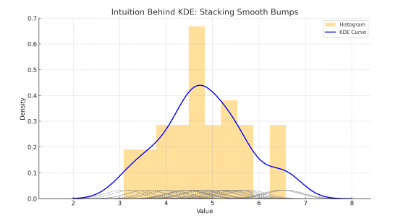

### From histogram to smooth curve (KDE)
KDE takes this a step further. Instead of stacking blocks, it places a smooth curve (a "bump") over each individual data point — like a mini hill.

These small hills are usually shaped like a bell curve (Gaussian), and when you add them all up, you get a smooth distribution curve that shows where the data "lives."

You can think of KDE as a way to ask:

                   "If I had infinitely many data points that looked like these, what shape would they form?"

### Why is it called a “density”?
Because:

It shows the relative likelihood of values.

The area under the curve is 1, just like probabilities in a distribution.

Even though it can go above 1 at some points (if the data is very concentrated), it’s not the height that matters but the area under the curve.

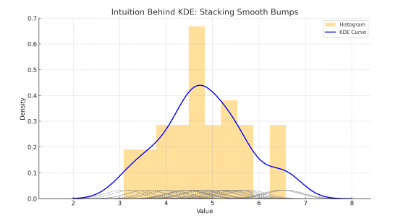



# 1.2 Box plot, Outliers and seaborn

***Problem***: 
 
Understanding Box Plots and Outliers in Python

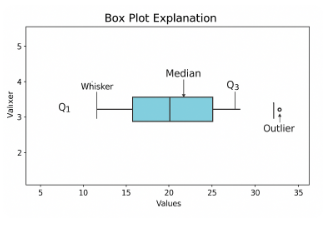


***Objective***:
In this exercise, you will:

Analyze a simple dataset

Compute key statistics (median, quartiles, IQR)

Identify outliers

Visualize the data using a box plot and distribution plot

***Background***:
A box plot is a graphical summary of a dataset that displays:

The minimum value

The first quartile (Q1) – the 25th percentile

The median (Q2) – the 50th percentile

The third quartile (Q3) – the 75th percentile

The maximum value

Any outliers in the data

Box plots help us understand the spread and skewness of the data.

***Statistical Definition of Outliers***:
Statisticians define an outlier as a data point that lies outside the range:

An **outlier** is a data point that lies outside the following range:

$$
[Q_1 - 1.5 \times IQR,\ Q_3 + 1.5 \times IQR]
$$

Where:

- $Q_1$ = First quartile (25th percentile)  
- $Q_3$ = Third quartile (75th percentile)  
- $IQR = Q_3 - Q_1$ = Interquartile range  



Any point below the lower bound or above the upper bound is considered an outlier.

***Instructions***:

Create a list of numbers (some typical values, plus one or two far-off values to act as outliers).

Use numpy to calculate the Q1, Q3, median, IQR, and detect any outliers.

Plot the data using:

A box plot

A violin plot or a KDE overlay to show distribution

Annotate the plot with vertical lines showing Q1, median, and Q3.

***Bonus***:

Explore how the box plot changes when:

You add more extreme values

You use sns.violinplot or sns.boxenplot to enhance the visualization





Q1: 9.5
Median: 12.0
Q3: 16.5
IQR: 7.0
Lower Bound: -1.0
Upper Bound: 27.0
Outliers: [30 35]


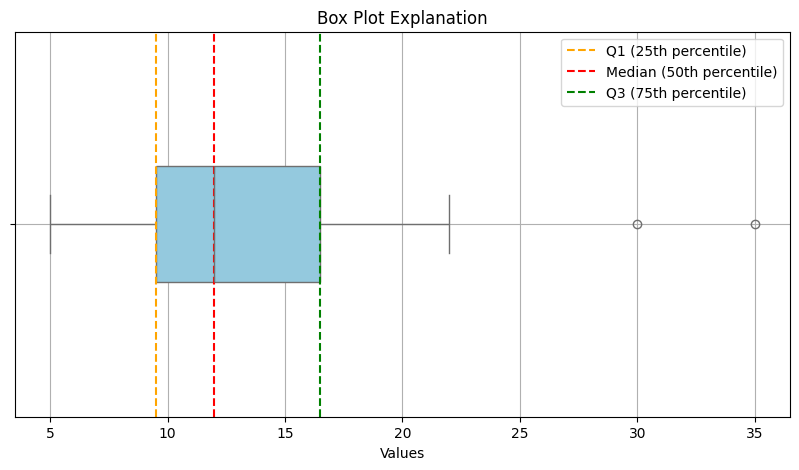

In [1]:
# Box Plot Explanation with Seaborn

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Define dataset (includes an outlier)
data = [5, 7, 8, 9, 10, 10, 11, 12, 13, 14, 15, 18, 22, 30, 35]

# Step 2: Calculate box plot statistics
data_np = np.array(data)
median = np.median(data_np)
q1 = np.percentile(data_np, 25)
q3 = np.percentile(data_np, 75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = data_np[(data_np < lower_bound) | (data_np > upper_bound)]

# Step 3: Print statistics
print(f"Q1: {q1}")
print(f"Median: {median}")
print(f"Q3: {q3}")
print(f"IQR: {iqr}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Outliers: {outliers}")

# Step 4: Create DataFrame for Seaborn
df = pd.DataFrame(data, columns=['Values'])

# Step 5: Plot box plot
plt.figure(figsize=(10, 5))
ax = sns.boxplot(x='Values', data=df, width=0.3, color='skyblue')
plt.title('Box Plot Explanation')
plt.grid(True)

# Annotate box plot with statistics
plt.axvline(q1, color='orange', linestyle='--', label='Q1 (25th percentile)')
plt.axvline(median, color='red', linestyle='--', label='Median (50th percentile)')
plt.axvline(q3, color='green', linestyle='--', label='Q3 (75th percentile)')
plt.legend()

plt.show()


### Interpretation:

Box edges: Q1 and Q3

Line inside the box: Median

Whiskers: Min and max values within 1.5×IQR

Dots: Outliers (if any, like 35)

# KDE Violin plot

###  What Does a Violin Plot Actually Represent?

This exercise shows how a **violin plot** is built from scratch.

1. We start with **raw data**, then:
2. Use **KDE (Kernel Density Estimation)** to estimate where the data is concentrated.
3. **Mirror the KDE** around a vertical axis → this creates the "violin" shape.
4. Combine it with a **box plot** to show quartiles and outliers.

> A violin plot = box plot + mirrored KDE


#### Kernel Density Estimation (KDE)

The **Kernel Density Estimation (KDE)** is a way to estimate the **probability density function** (PDF) of a dataset:

$$
\hat{f}_h(x) = \frac{1}{n h} \sum_{i=1}^{n} K\left( \frac{x - x_i}{h} \right)
$$

Where:

$$
\hat{f}_h(x) \quad \text{: Estimated probability density at location } x
$$

$$
n \quad \text{: Total number of observations}
$$

$$
h \quad \text{: Bandwidth parameter (controls the smoothness of the curve)}
$$

$$
x_i \quad \text{: The } i^{\text{th}} \text{ data point in the sample}
$$

$$
K(\cdot) \quad \text{: The kernel function (e.g., Gaussian)}
$$


For a **Gaussian kernel**, we have:

$$
K(u) = \frac{1}{\sqrt{2\pi}} e^{- \frac{1}{2} u^2}
$$

This results in a **smooth distribution curve** — KDE adds a small “bump” (kernel) at each data point and adds them all together.

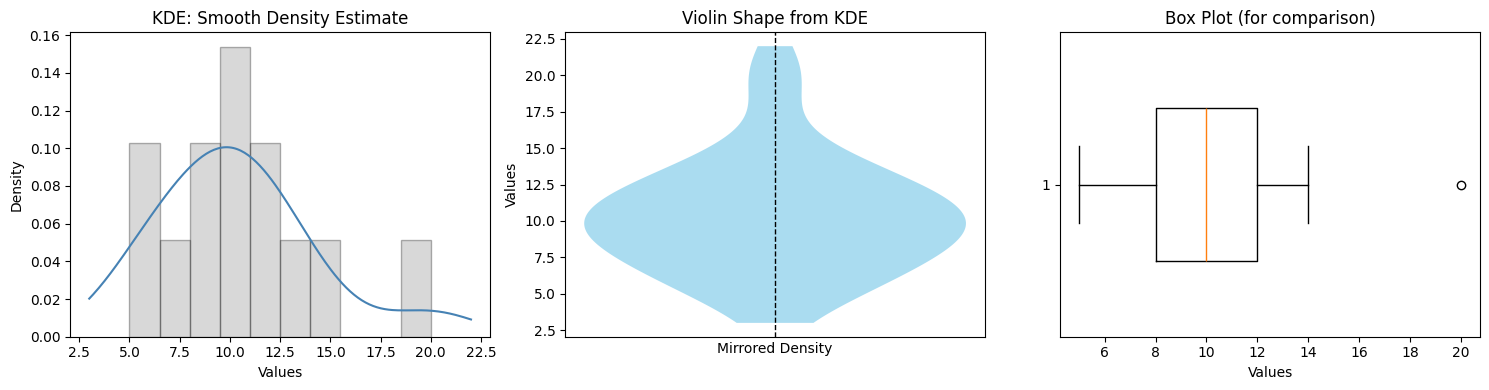

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Step 1: Raw data (a 1D list/array)
data = np.array([5, 6, 7, 8, 9, 10, 10, 10, 11, 12, 13, 14, 20])

# Step 2: Compute KDE using gaussian_kde
kde = gaussian_kde(data)
x_vals = np.linspace(min(data) - 2, max(data) + 2, 200)
kde_vals = kde(x_vals)

# Step 3: Plot the KDE
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(data, bins=10, density=True, alpha=0.3, color='gray', edgecolor='black')
plt.plot(x_vals, kde_vals, color='steelblue')
plt.title("KDE: Smooth Density Estimate")
plt.xlabel("Values")
plt.ylabel("Density")

# Step 4: Simulate a violin plot manually (mirrored KDE)
plt.subplot(1, 3, 2)
plt.fill_betweenx(x_vals, -kde_vals, kde_vals, facecolor='skyblue', alpha=0.7)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title("Violin Shape from KDE")
plt.xlabel("Mirrored Density")
plt.ylabel("Values")
plt.xticks([])

# Step 5: Add box plot
plt.subplot(1, 3, 3)
plt.boxplot(data, vert=False, widths=0.5)
plt.title("Box Plot (for comparison)")
plt.xlabel("Values")

plt.tight_layout()
plt.show()


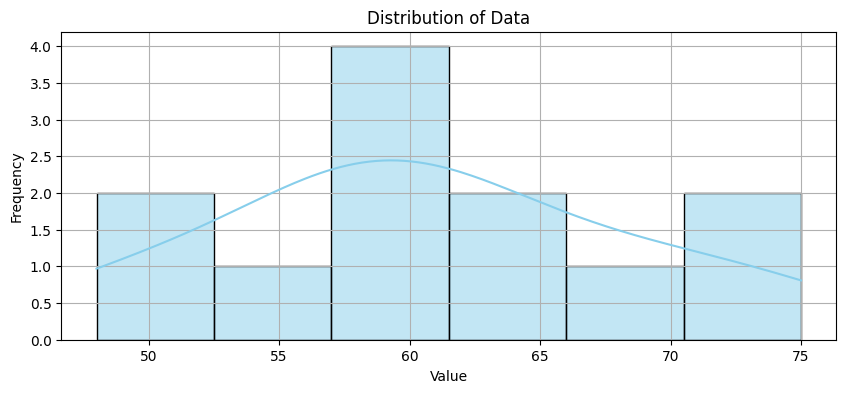

In [8]:
plt.figure(figsize=(10, 4))
sns.histplot(data, bins=6, kde=True, color='skyblue')
plt.title("Distribution of Data")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()